In [1]:
AVAILABLE_SEASSONS = [
    '2021', '2022', '2023',
    '2024', '2025', '2026'
]

TAG_TEAM = 42
TAG_TEAM_NAME = "ARSENAL"

In [2]:

# Selecciones nacionales
TAG_LEAGUES = [1, 4, 5, 9, 10, 21, 22, 31, 32, 37, 536, 960]

# Premier league (Inglaterra)
TAG_LEAGUES = [39]

### Librerias

In [3]:
from google.colab import userdata

import pandas as pd
import json

# Numeric
import numpy as np
import math

# API
import time
from tqdm.notebook import tqdm
import requests
import http.client

# Visualizations
import seaborn as sns
import matplotlib.pyplot as plt

# ML
from scipy.stats import poisson
from sklearn.linear_model import PoissonRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings

## **Pasos iniciales**

* Funciones para hacer llamadas a la API de datos (API-FOOTBALL)

### Función para hacer llamadas a la API

In [4]:
def get_dataframe_api(endpoint:str):

  url = f"https://v3.football.api-sports.io/{endpoint}"
  headers = {
    "x-apisports-key": userdata.get("api-football-key")
  }

  r = requests.get(url=url,
                   headers=headers)

  print(f"No. errors: ", len(r.json()['errors']))
  print(f"No. results: ", r.json()['results'])
  print(f"----\n\n\n")

  return r.json()['response'], r.json()['results']

### Función para obtener el ID de los torenos del equipo seleccionado

In [5]:
def get_tag_leagues_from_especify_team():
  leagues = set()

  for sesson in AVAILABLE_SEASSONS:

    endpoint_fixtures = f"fixtures?team={TAG_TEAM}&season={sesson}"

    data_fixtures, num_api_results = get_dataframe_api(endpoint_fixtures)

    data_fixtures

    for match in data_fixtures:
        leagues.add(match["league"]["id"])

    print(f"--> Sesson: {sesson} - {leagues} <--\n\n")

  tag_leagues = np.array(sorted(leagues))

  return tag_leagues

In [6]:
TAG_LEAGUES = get_tag_leagues_from_especify_team()

No. errors:  0
No. results:  52
----



--> Sesson: 2021 - {48, 667, 45, 39} <--


No. errors:  0
No. results:  57
----



--> Sesson: 2022 - {3, 39, 937, 45, 48, 667} <--


No. errors:  0
No. results:  57
----



--> Sesson: 2023 - {866, 3, 2, 39, 937, 45, 48, 528, 667} <--


No. errors:  0
No. results:  63
----



--> Sesson: 2024 - {866, 3, 2, 39, 937, 45, 48, 528, 667} <--


No. errors:  0
No. results:  69
----



--> Sesson: 2025 - {866, 3, 2, 39, 937, 45, 48, 528, 667} <--


No. errors:  0
No. results:  1
----



--> Sesson: 2026 - {866, 3, 2, 39, 937, 45, 48, 528, 667} <--




### <font color=purple>Obtener un dataframe de un equipo específcio</font>
 * Obtiene todos los partidos de todas las ligas en las que juega el equipo

In [7]:
def get_clean_fixtures(data, target_id=42):
  processed_matches = []

  for m in data:
    is_home = m['teams']['home']['id'] == target_id

    status_match = m['fixture']['status']['short']


    if status_match != 'FT':
      continue

    team_side = 'home' if is_home else 'away'
    rival_side = 'away' if is_home else 'home'

    match_info = {
            'fixture_id': m['fixture']['id'],
            'season': m['league']['season'],
            'date': m['fixture']['date'],
            'team_name': m['teams'][team_side]['name'],
            'opponent_name': m['teams'][rival_side]['name'],
            'match_result': m['teams'][team_side]['winner'],
            'goals_for': m['goals'][team_side],
            'goals_against': m['goals'][rival_side],
            'is_home': is_home
    }

    processed_matches.append(match_info)

  return pd.DataFrame(processed_matches)

In [8]:
def get_general_results_matches():

  df_fixtures_all_sessons = []

  for sesson in AVAILABLE_SEASSONS:
    print(f"SEASON: {sesson}")

    for id_league in TAG_LEAGUES:
      print(f"ID LEAGUE: {id_league}")

      endpoint_fixtures = f"fixtures?league={id_league}&season={sesson}&team={TAG_TEAM}"

      data_fixtures, num_api_results = get_dataframe_api(endpoint_fixtures)

      if num_api_results < 1:
        continue

      df_fixtures_per_sesson = get_clean_fixtures(data_fixtures,
                                                  target_id=TAG_TEAM)

      df_fixtures_all_sessons.append(df_fixtures_per_sesson)

  df_fixtures_all_sessons = pd.concat(df_fixtures_all_sessons,
                                      ignore_index=True)

  return df_fixtures_all_sessons

### <font color="green">Obtener un dataframe de un todos los equipos</font>
 * Obtiene todos los partidos de todas las ligas especificadas en TAG_LEAGUES

In [9]:
def get_clean_fixtures_all_teams(data):
  processed_matches = []

  for m in data:
    status_match = m['fixture']['status']['short']


    if status_match != 'FT':
      continue


    match_info = {
            'fixture_id': m['fixture']['id'],
            'season': m['league']['season'],
            'date': m['fixture']['date'],
            'home_team': m['teams']['home']['name'],
            'away_team': m['teams']['away']['name'],
            'home_goals': m['goals']['home'],
            'away_goals': m['goals']['away']
    }

    processed_matches.append(match_info)

  return pd.DataFrame(processed_matches)

In [10]:
def get_general_results_matches_all_teams():

  df_fixtures_all_sessons = []

  for sesson in AVAILABLE_SEASSONS:
    print(f"SEASON: {sesson}")

    for id_league in TAG_LEAGUES:
      print(f"ID LEAGUE: {id_league}")

      endpoint_fixtures = f"fixtures?league={id_league}&season={sesson}"

      data_fixtures, num_api_results = get_dataframe_api(endpoint_fixtures)

      if num_api_results < 1:
        continue

      df_fixtures_per_sesson = get_clean_fixtures_all_teams(data_fixtures)

      df_fixtures_all_sessons.append(df_fixtures_per_sesson)

  df_fixtures_all_sessons = pd.concat(df_fixtures_all_sessons,
                                      ignore_index=True)

  return df_fixtures_all_sessons

## 📊 <font color=#258FE8>**EDA**</font> (Avance 1)

### Mostrar el data DF con estadísticas generales de los partidos

* Oponente
* Resultado
* Goles a favor
* Goles encontra
* ¿Es visitante?

In [11]:
df_fixtures_all_sessons = get_general_results_matches()

SEASON: 2021
ID LEAGUE: 2
No. errors:  0
No. results:  0
----



ID LEAGUE: 3
No. errors:  0
No. results:  0
----



ID LEAGUE: 39
No. errors:  0
No. results:  38
----



ID LEAGUE: 45
No. errors:  0
No. results:  1
----



ID LEAGUE: 48
No. errors:  0
No. results:  6
----



ID LEAGUE: 528
No. errors:  0
No. results:  0
----



ID LEAGUE: 667
No. errors:  0
No. results:  7
----



ID LEAGUE: 866
No. errors:  0
No. results:  0
----



ID LEAGUE: 937
No. errors:  0
No. results:  0
----



SEASON: 2022
ID LEAGUE: 2
No. errors:  0
No. results:  0
----



ID LEAGUE: 3
No. errors:  0
No. results:  8
----



ID LEAGUE: 39
No. errors:  0
No. results:  38
----



ID LEAGUE: 45
No. errors:  0
No. results:  2
----



ID LEAGUE: 48
No. errors:  0
No. results:  1
----



ID LEAGUE: 528
No. errors:  0
No. results:  0
----



ID LEAGUE: 667
No. errors:  0
No. results:  7
----



ID LEAGUE: 866
No. errors:  0
No. results:  0
----



ID LEAGUE: 937
No. errors:  0
No. results:  1
----



SEASON: 2023
I

In [12]:
df_fixtures_all_sessons.shape

(283, 9)

In [13]:
df_fixtures_all_sessons.head()

,fixture_id,season,date,team_name,opponent_name,match_result,goals_for,goals_against,is_home
0,710556,2021,2021-08-13T19:00:00+00:00,Arsenal,Brentford,False,0,2,False
1,710566,2021,2021-08-22T15:30:00+00:00,Arsenal,Chelsea,False,0,2,True
2,710580,2021,2021-08-28T11:30:00+00:00,Arsenal,Manchester City,False,0,5,False
3,710586,2021,2021-09-11T14:00:00+00:00,Arsenal,Norwich,True,1,0,True
4,710598,2021,2021-09-18T14:00:00+00:00,Arsenal,Burnley,True,1,0,False


Nota: Convertimos la columna 'date' a tipo de dato de fecha

In [14]:
df_fixtures_all_sessons['date'] = pd.to_datetime(df_fixtures_all_sessons['date'])
df_fixtures_all_sessons = df_fixtures_all_sessons.sort_values(by='date')
df_fixtures_all_sessons.head(2)

,fixture_id,season,date,team_name,opponent_name,match_result,goals_for,goals_against,is_home
46,736003,2021,2021-07-13 17:00:00+00:00,Arsenal,Hibernian,False,1,2,False
45,735990,2021,2021-07-17 13:00:00+00:00,Arsenal,Rangers,None,2,2,False


### Obtener estadísticas profundas de los partidos

In [15]:
df_fixtures_all_sessons_stats = []
df_no_match_information = []

for index, fixture in df_fixtures_all_sessons.iterrows():

  # Plan Pro: 300 requests per minute
  if index > 0 and (index % 300 == 0):
    for i in tqdm(range(65)):
      time.sleep(1)


  endpoint_fixtures_stats = f"fixtures/statistics?fixture={fixture['fixture_id']}&half=false"

  print(f"Index No: {index}")
  print(f"ID partido: {fixture['fixture_id']}")
  print(f"Enpoint: {endpoint_fixtures_stats}")

  data, _ = get_dataframe_api(endpoint_fixtures_stats)

  print(data)

  if not data:
    print("No match information")
    df_no_match_information.append(fixture['fixture_id'])
    continue

  team_target = next(item for item in data if item["team"]["id"] == TAG_TEAM)
  team_rival = next(item for item in data if item["team"]["id"] != TAG_TEAM)

  stats_target = {item['type']: item['value'] for item in team_target['statistics']}
  stats_rival = {item['type']: item['value'] for item in team_rival['statistics']}

  df = pd.DataFrame([{
    'team_id': team_target['team']['id'],
    'team_name': team_target['team']['name'],
    'total_shots': stats_target.get("Total Shots"),
    'shots_on_goal': stats_target.get("Shots on Goal"),
    'fouls': stats_target.get("Fouls"),
    'corner_kicks': stats_target.get("Corner Kicks"),
    'offsides': stats_target.get("Offsides"),
    'ball_possession': stats_target.get("Ball Possession"),
    'yellow_cards': stats_target.get("Yellow Cards"),
    'goalkeeper_saves': stats_target.get("Goalkeeper Saves"),
    'passes_percentage': stats_target.get("Passes %"),
    'total_passes': stats_target.get("Total passes"),
    'passes_accurate': stats_target.get("Passes accurate"),
    'shots_received': stats_rival.get("Total Shots"),
    'shots_on_goal_received': stats_rival.get("Shots on Goal"),
    'fixture_id': fixture['fixture_id'],
    'match_result': fixture['match_result'],
    'goals_for': fixture['goals_for'],
    'goals_against': fixture['goals_against'],
    'is_home': fixture['is_home'],
    'season': fixture['season']
  }])

  df_fixtures_all_sessons_stats.append(df)

print(f"{len(df_fixtures_all_sessons)}/{len(df_no_match_information)}")

df_fixtures_all_sessons_stats = pd.concat(df_fixtures_all_sessons_stats,
                                          ignore_index=True)

Index No: 46
ID partido: 736003
Enpoint: fixtures/statistics?fixture=736003&half=false
No. errors:  0
No. results:  0
----



[]
No match information
Index No: 45
ID partido: 735990
Enpoint: fixtures/statistics?fixture=735990&half=false
No. errors:  0
No. results:  0
----



[]
No match information
Index No: 49
ID partido: 745381
Enpoint: fixtures/statistics?fixture=745381&half=false
No. errors:  0
No. results:  0
----



[]
No match information
Index No: 50
ID partido: 748877
Enpoint: fixtures/statistics?fixture=748877&half=false
No. errors:  0
No. results:  0
----



[]
No match information
Index No: 47
ID partido: 736041
Enpoint: fixtures/statistics?fixture=736041&half=false
No. errors:  0
No. results:  0
----



[]
No match information
Index No: 48
ID partido: 736045
Enpoint: fixtures/statistics?fixture=736045&half=false
No. errors:  0
No. results:  0
----



[]
No match information
Index No: 0
ID partido: 710556
Enpoint: fixtures/statistics?fixture=710556&half=false
No. errors:  0

Nota: Convertirmos la columna 'ball_possession' y 'passes_percentage' a un valor floante/numérico (quitando el símbolo de porcentaje)

In [16]:
df_fixtures_all_sessons_stats['ball_possession'] = df_fixtures_all_sessons_stats['ball_possession'].str.replace('%', '').astype(float) / 100

df_fixtures_all_sessons_stats['passes_percentage'] = df_fixtures_all_sessons_stats['passes_percentage'].str.replace('%', '').astype(float) / 100

df_fixtures_all_sessons_stats[['passes_percentage', 'ball_possession']].head(2)

,passes_percentage,ball_possession
0,0.86,0.65
1,0.79,0.35


In [17]:
df_fixtures_all_sessons_stats['corner_kicks'] = pd.to_numeric(df_fixtures_all_sessons_stats['corner_kicks'], errors='coerce')
df_fixtures_all_sessons_stats['offsides'] = pd.to_numeric(df_fixtures_all_sessons_stats['offsides'], errors='coerce')
df_fixtures_all_sessons_stats['yellow_cards'] = pd.to_numeric(df_fixtures_all_sessons_stats['yellow_cards'], errors='coerce')


df_fixtures_all_sessons_stats[['corner_kicks', 'offsides', 'yellow_cards']].head(2)

,corner_kicks,offsides,yellow_cards
0,5.0,1.0,NaN
1,9.0,5.0,3.0


In [18]:
df = df_fixtures_all_sessons_stats.copy()

### **<font color='orange'>Primer vistazo</font>**

In [19]:
print(f"{len(df_no_match_information)} matches have not information about it")

print(f"\n\n{df.shape}\n\n")

df.head()

19 matches have not information about it


(264, 21)




,team_id,team_name,total_shots,shots_on_goal,fouls,corner_kicks,offsides,ball_possession,yellow_cards,goalkeeper_saves,...,total_passes,passes_accurate,shots_received,shots_on_goal_received,fixture_id,match_result,goals_for,goals_against,is_home,season
0,42,Arsenal,22,4,8,5.0,1.0,0.65,NaN,1,...,568,488,8,3,710556,False,0,2,False,2021
1,42,Arsenal,6,3,10,9.0,5.0,0.35,3.0,3,...,335,266,22,5,710566,False,0,2,True,2021
2,42,Arsenal,14,9,5,3.0,2.0,0.74,2.0,4,...,640,566,11,4,766563,True,6,0,False,2021
3,42,Arsenal,1,0,7,0.0,3.0,0.20,2.0,5,...,185,125,25,10,710580,False,0,5,False,2021
4,42,Arsenal,30,7,9,8.0,2.0,0.52,1.0,1,...,437,365,10,1,710586,True,1,0,True,2021


### **<font color='orange'>Descripción general de la forma y los tipos de datos</font>**

In [20]:
print("Dimensiones del dataset de partidos:", df.shape)
print("\nColumnas disponibles:")
display(df.columns.tolist())

print("\nTipos de datos:")
print(df.dtypes)

display(df.head())


Dimensiones del dataset de partidos: (264, 21)

Columnas disponibles:


['team_id',
 'team_name',
 'total_shots',
 'shots_on_goal',
 'fouls',
 'corner_kicks',
 'offsides',
 'ball_possession',
 'yellow_cards',
 'goalkeeper_saves',
 'passes_percentage',
 'total_passes',
 'passes_accurate',
 'shots_received',
 'shots_on_goal_received',
 'fixture_id',
 'match_result',
 'goals_for',
 'goals_against',
 'is_home',
 'season']


Tipos de datos:
team_id                     int64
team_name                  object
total_shots                 int64
shots_on_goal               int64
fouls                       int64
corner_kicks              float64
offsides                  float64
ball_possession           float64
yellow_cards              float64
goalkeeper_saves           object
passes_percentage         float64
total_passes                int64
passes_accurate             int64
shots_received              int64
shots_on_goal_received      int64
fixture_id                  int64
match_result               object
goals_for                   int64
goals_against               int64
is_home                      bool
season                      int64
dtype: object


,team_id,team_name,total_shots,shots_on_goal,fouls,corner_kicks,offsides,ball_possession,yellow_cards,goalkeeper_saves,...,total_passes,passes_accurate,shots_received,shots_on_goal_received,fixture_id,match_result,goals_for,goals_against,is_home,season
0,42,Arsenal,22,4,8,5.0,1.0,0.65,NaN,1,...,568,488,8,3,710556,False,0,2,False,2021
1,42,Arsenal,6,3,10,9.0,5.0,0.35,3.0,3,...,335,266,22,5,710566,False,0,2,True,2021
2,42,Arsenal,14,9,5,3.0,2.0,0.74,2.0,4,...,640,566,11,4,766563,True,6,0,False,2021
3,42,Arsenal,1,0,7,0.0,3.0,0.20,2.0,5,...,185,125,25,10,710580,False,0,5,False,2021
4,42,Arsenal,30,7,9,8.0,2.0,0.52,1.0,1,...,437,365,10,1,710586,True,1,0,True,2021


### **<font color='orange'>Valores faltantes en el conjunto de datos</font>**

,missing_count,missing_percent
team_id,0,0.00
team_name,0,0.00
total_shots,0,0.00
shots_on_goal,0,0.00
fouls,0,0.00
corner_kicks,1,0.38
offsides,12,4.55
ball_possession,0,0.00
yellow_cards,12,4.55
goalkeeper_saves,1,0.38


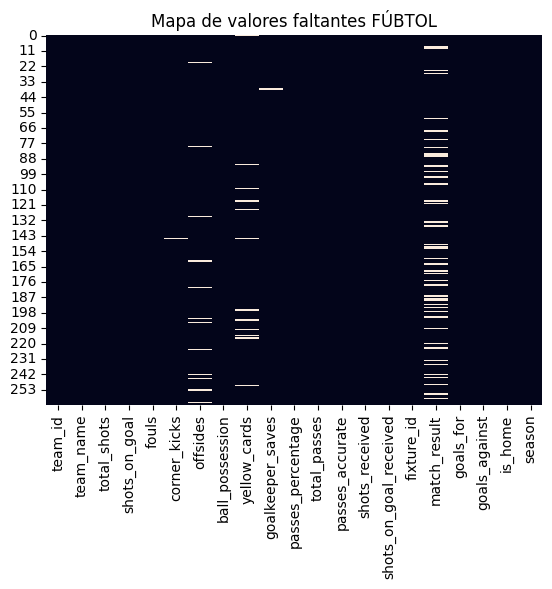

In [21]:
missing_count = df.isnull().sum()
missing_percent = (df.isnull().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent
})

display(missing_summary)

sns.heatmap(df.isnull(), cbar=False)
plt.title("Mapa de valores faltantes FÚBTOL")
plt.show()


### **<font color='orange'>Estadísticas descriptivas y de frecuencia</font>**

In [22]:
df.drop(columns=['team_id', 'fixture_id', 'season']).describe().T

,count,mean,std,min,25%,50%,75%,max
total_shots,264.0,15.015152,5.614328,1.00,11.0000,14.00,18.00,36.00
shots_on_goal,264.0,5.268939,2.633439,0.00,3.0000,5.00,7.00,16.00
fouls,264.0,10.132576,3.482908,0.00,8.0000,10.00,12.00,22.00
corner_kicks,263.0,6.022814,3.218424,0.00,4.0000,5.00,8.00,17.00
offsides,252.0,1.857143,1.467927,0.00,1.0000,2.00,3.00,8.00
ball_possession,264.0,0.566439,0.115041,0.20,0.4900,0.57,0.65,0.82
yellow_cards,252.0,1.650794,1.248537,0.00,1.0000,1.00,2.00,6.00
passes_percentage,264.0,0.847614,0.049836,0.49,0.8275,0.86,0.88,0.93
total_passes,264.0,501.564394,117.902114,88.00,432.5000,500.00,581.25,895.00
passes_accurate,264.0,429.553030,117.366432,69.00,359.7500,423.50,503.50,827.00


Nota: Match result se divide en

1.   True: Partido ganado
2.   False: Partido perdido
3.   None: Partido empatado



In [23]:
df.drop(columns=['team_id', 'fixture_id']).describe(include=['object', 'bool']).T

,count,unique,top,freq
team_name,264,1,Arsenal,264
goalkeeper_saves,263,10,1,78
match_result,219,2,True,168
is_home,264,2,False,133


In [24]:
display(df['match_result'].value_counts(dropna=False))

,count
match_result,
True,168
False,51
None,45


### Hacer el resultado del partido en categorías tipo 'one-hot-encoding'

* Victoria = 2
* Empate = 1
* Derrota = 0

In [25]:
df['is_home'] = pd.Categorical(df['is_home'],
                                    categories=[True, False])

df['match_result'] = pd.Categorical(df['match_result'],
                                    categories=[True, False])

df_dummies = pd.get_dummies(df['match_result'],
                            prefix='res',
                            dummy_na=True)

df_dummies = df_dummies.rename(columns={
    'res_True': 'victoria',
    'res_False': 'derrota',
    'res_nan': 'empate'
})

df = pd.concat([df,
                df_dummies], axis=1)

mapping = {
    'victoria': 2, # Changed from 3 to 2
    'empate': 1,
    'derrota': 0
}

df['result_num'] = df[['victoria', 'empate', 'derrota']].idxmax(axis=1).map(mapping)

df.head(25)

,team_id,team_name,total_shots,shots_on_goal,fouls,corner_kicks,offsides,ball_possession,yellow_cards,goalkeeper_saves,...,fixture_id,match_result,goals_for,goals_against,is_home,season,victoria,derrota,empate,result_num
0,42,Arsenal,22,4,8,5.0,1.0,0.65,NaN,1,...,710556,False,0,2,False,2021,False,True,False,0
1,42,Arsenal,6,3,10,9.0,5.0,0.35,3.0,3,...,710566,False,0,2,True,2021,False,True,False,0
2,42,Arsenal,14,9,5,3.0,2.0,0.74,2.0,4,...,766563,True,6,0,False,2021,True,False,False,2
3,42,Arsenal,1,0,7,0.0,3.0,0.20,2.0,5,...,710580,False,0,5,False,2021,False,True,False,0
4,42,Arsenal,30,7,9,8.0,2.0,0.52,1.0,1,...,710586,True,1,0,True,2021,True,False,False,2
5,42,Arsenal,13,3,8,3.0,2.0,0.55,1.0,3,...,710598,True,1,0,False,2021,True,False,False,2
6,42,Arsenal,19,5,8,10.0,2.0,0.62,0.0,0,...,787058,True,3,0,True,2021,True,False,False,2
7,42,Arsenal,12,7,12,4.0,2.0,0.47,2.0,3,...,710606,True,3,1,True,2021,True,False,False,2
8,42,Arsenal,8,2,5,5.0,1.0,0.42,1.0,2,...,710616,NaN,0,0,False,2021,False,False,True,1
9,42,Arsenal,17,6,7,6.0,0.0,0.54,1.0,4,...,710626,NaN,2,2,True,2021,False,False,True,1


### Eliminamos columnas que repiten información o cuyo valor no es relevante

In [26]:
columns_to_drop = ['team_id', 'team_name', 'fixture_id',
                   'match_result',
                   'victoria', 'derrota', 'empate']

df = df.drop(columns_to_drop, axis=1)

df.head(2)

,total_shots,shots_on_goal,fouls,corner_kicks,offsides,ball_possession,yellow_cards,goalkeeper_saves,passes_percentage,total_passes,passes_accurate,shots_received,shots_on_goal_received,goals_for,goals_against,is_home,season,result_num
0,22,4,8,5.0,1.0,0.65,NaN,1,0.86,568,488,8,3,0,2,False,2021,0
1,6,3,10,9.0,5.0,0.35,3.0,3,0.79,335,266,22,5,0,2,True,2021,0


### **<font color='pink'>Matriz de correlación</font>**

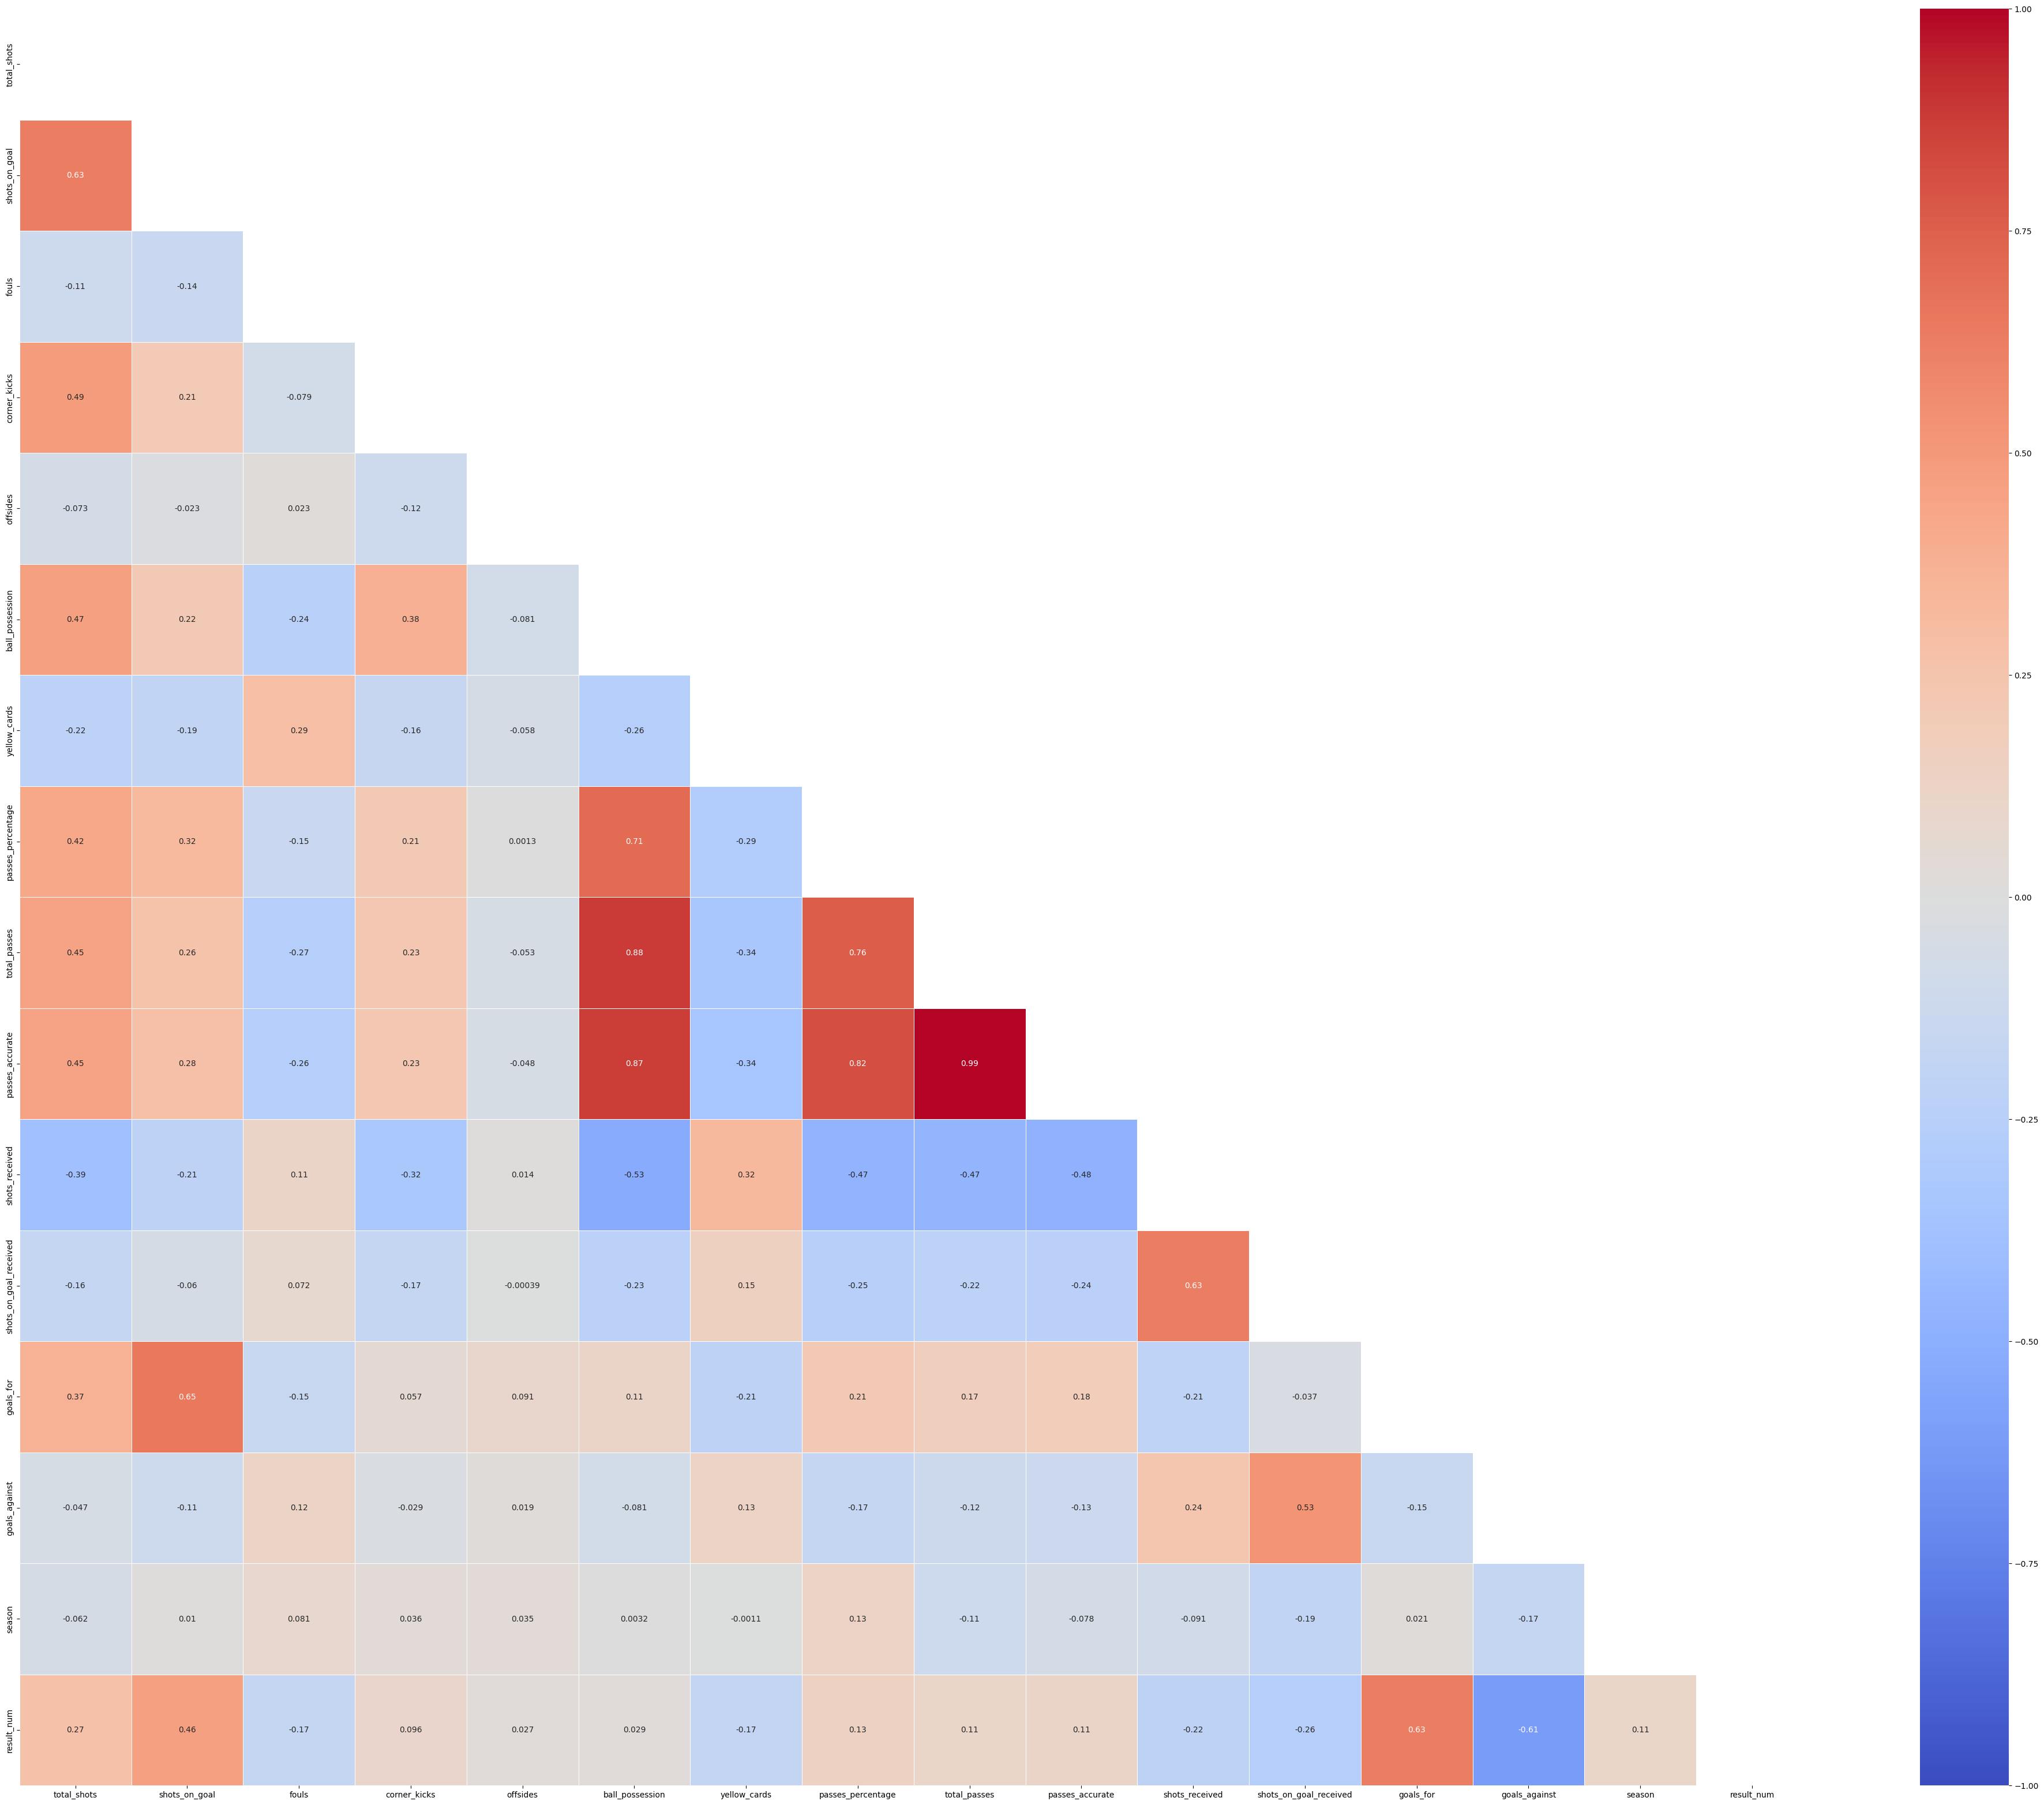

In [27]:
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

# Crear una máscara para la mitad superior
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(50, 40))
sns.heatmap(
    corr_matrix,
    mask=mask,       # Aplicar la máscara
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5
)
plt.show()

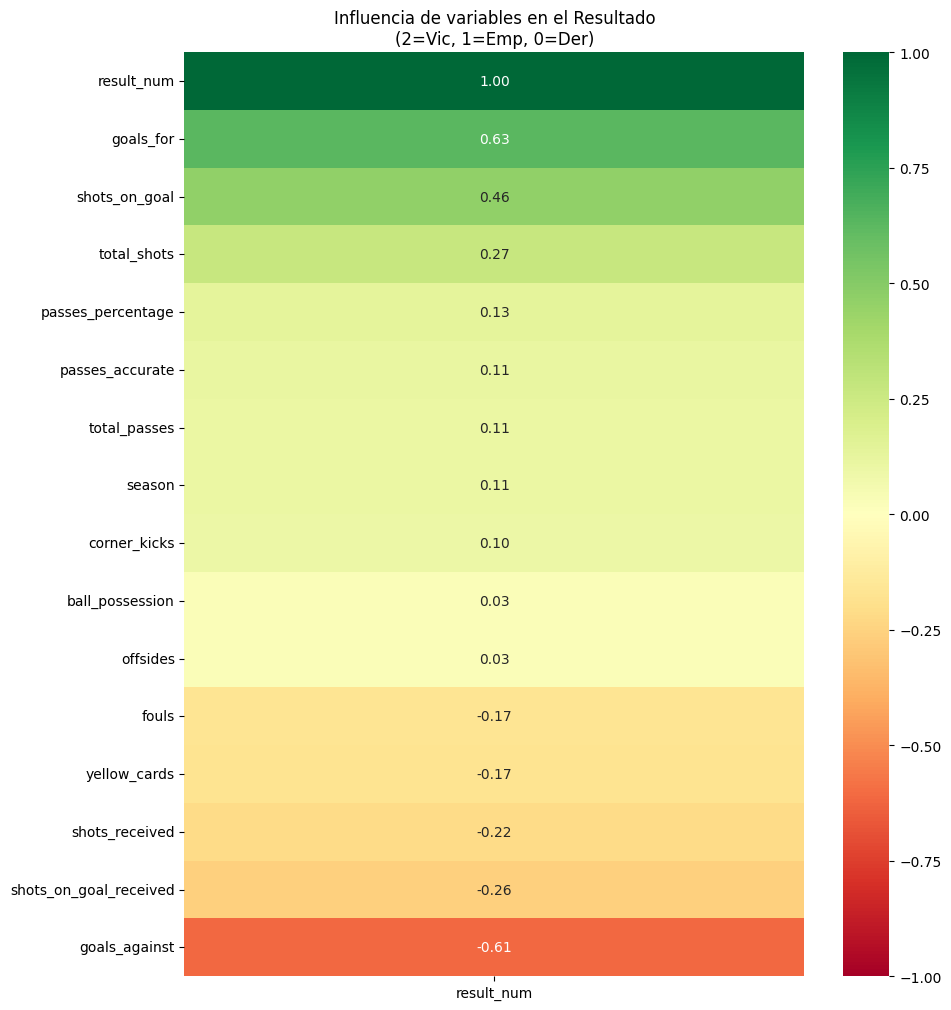

In [28]:
plt.figure(figsize=(10, 12))

# Ordenamos las correlaciones respecto a 'result_num'
res_corr = corr_matrix[['result_num']].sort_values(by='result_num', ascending=False)

sns.heatmap(
    res_corr,
    annot=True,
    cmap='RdYlGn', # Verde para correlación positiva (victoria), rojo para negativa
    vmin=-1, vmax=1,
    fmt=".2f"
)

plt.title('Influencia de variables en el Resultado\n(2=Vic, 1=Emp, 0=Der)')
plt.show()

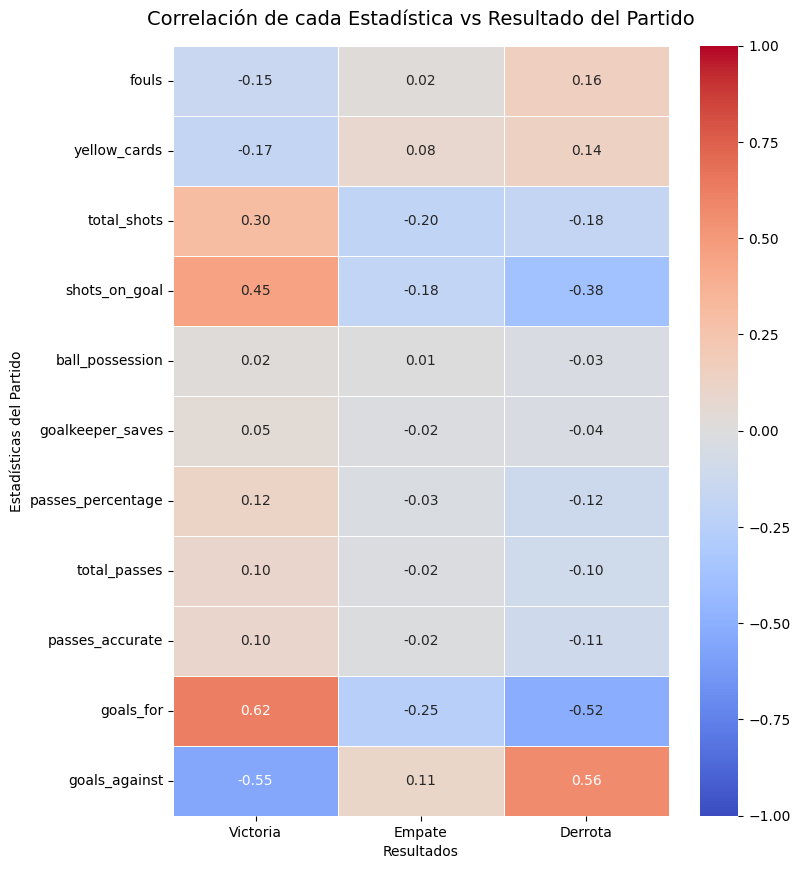

In [29]:
# 1. Creamos variables temporales binarias (1 si ocurre, 0 si no)
df_temp = df.copy()
df_temp['Victoria'] = (df_temp['result_num'] == 2).astype(int)
df_temp['Empate'] = (df_temp['result_num'] == 1).astype(int)
df_temp['Derrota'] = (df_temp['result_num'] == 0).astype(int)

# 2. Definimos las columnas de resultados y las estadísticas que ya tenías
col_resultados = ['Victoria', 'Empate', 'Derrota']
colums_analyze = ['fouls', 'yellow_cards', 'total_shots', 'shots_on_goal',
                  'ball_possession',
                  'goalkeeper_saves', 'passes_percentage', 'total_passes',
                  'passes_accurate', 'goals_for', 'goals_against']

# 3. Calculamos la correlación solo entre estadísticas y los resultados
corr_resultados = df_temp[colums_analyze + col_resultados].corr().loc[colums_analyze, col_resultados]

# 4. Graficamos el Heatmap aislado
plt.figure(figsize=(8, 10)) # Un tamaño más vertical y cómodo de leer
sns.heatmap(
    corr_resultados,
    annot=True,       # Muestra el número
    fmt=".2f",        # 2 decimales
    cmap='coolwarm',  # Azul (negativo), Rojo (positivo)
    vmin=-1, vmax=1,
    linewidths=0.5
)

plt.title('Correlación de cada Estadística vs Resultado del Partido', fontsize=14, pad=15)
plt.ylabel('Estadísticas del Partido')
plt.xlabel('Resultados')
plt.show()

### **<font color='pink'>Outliers</font>**

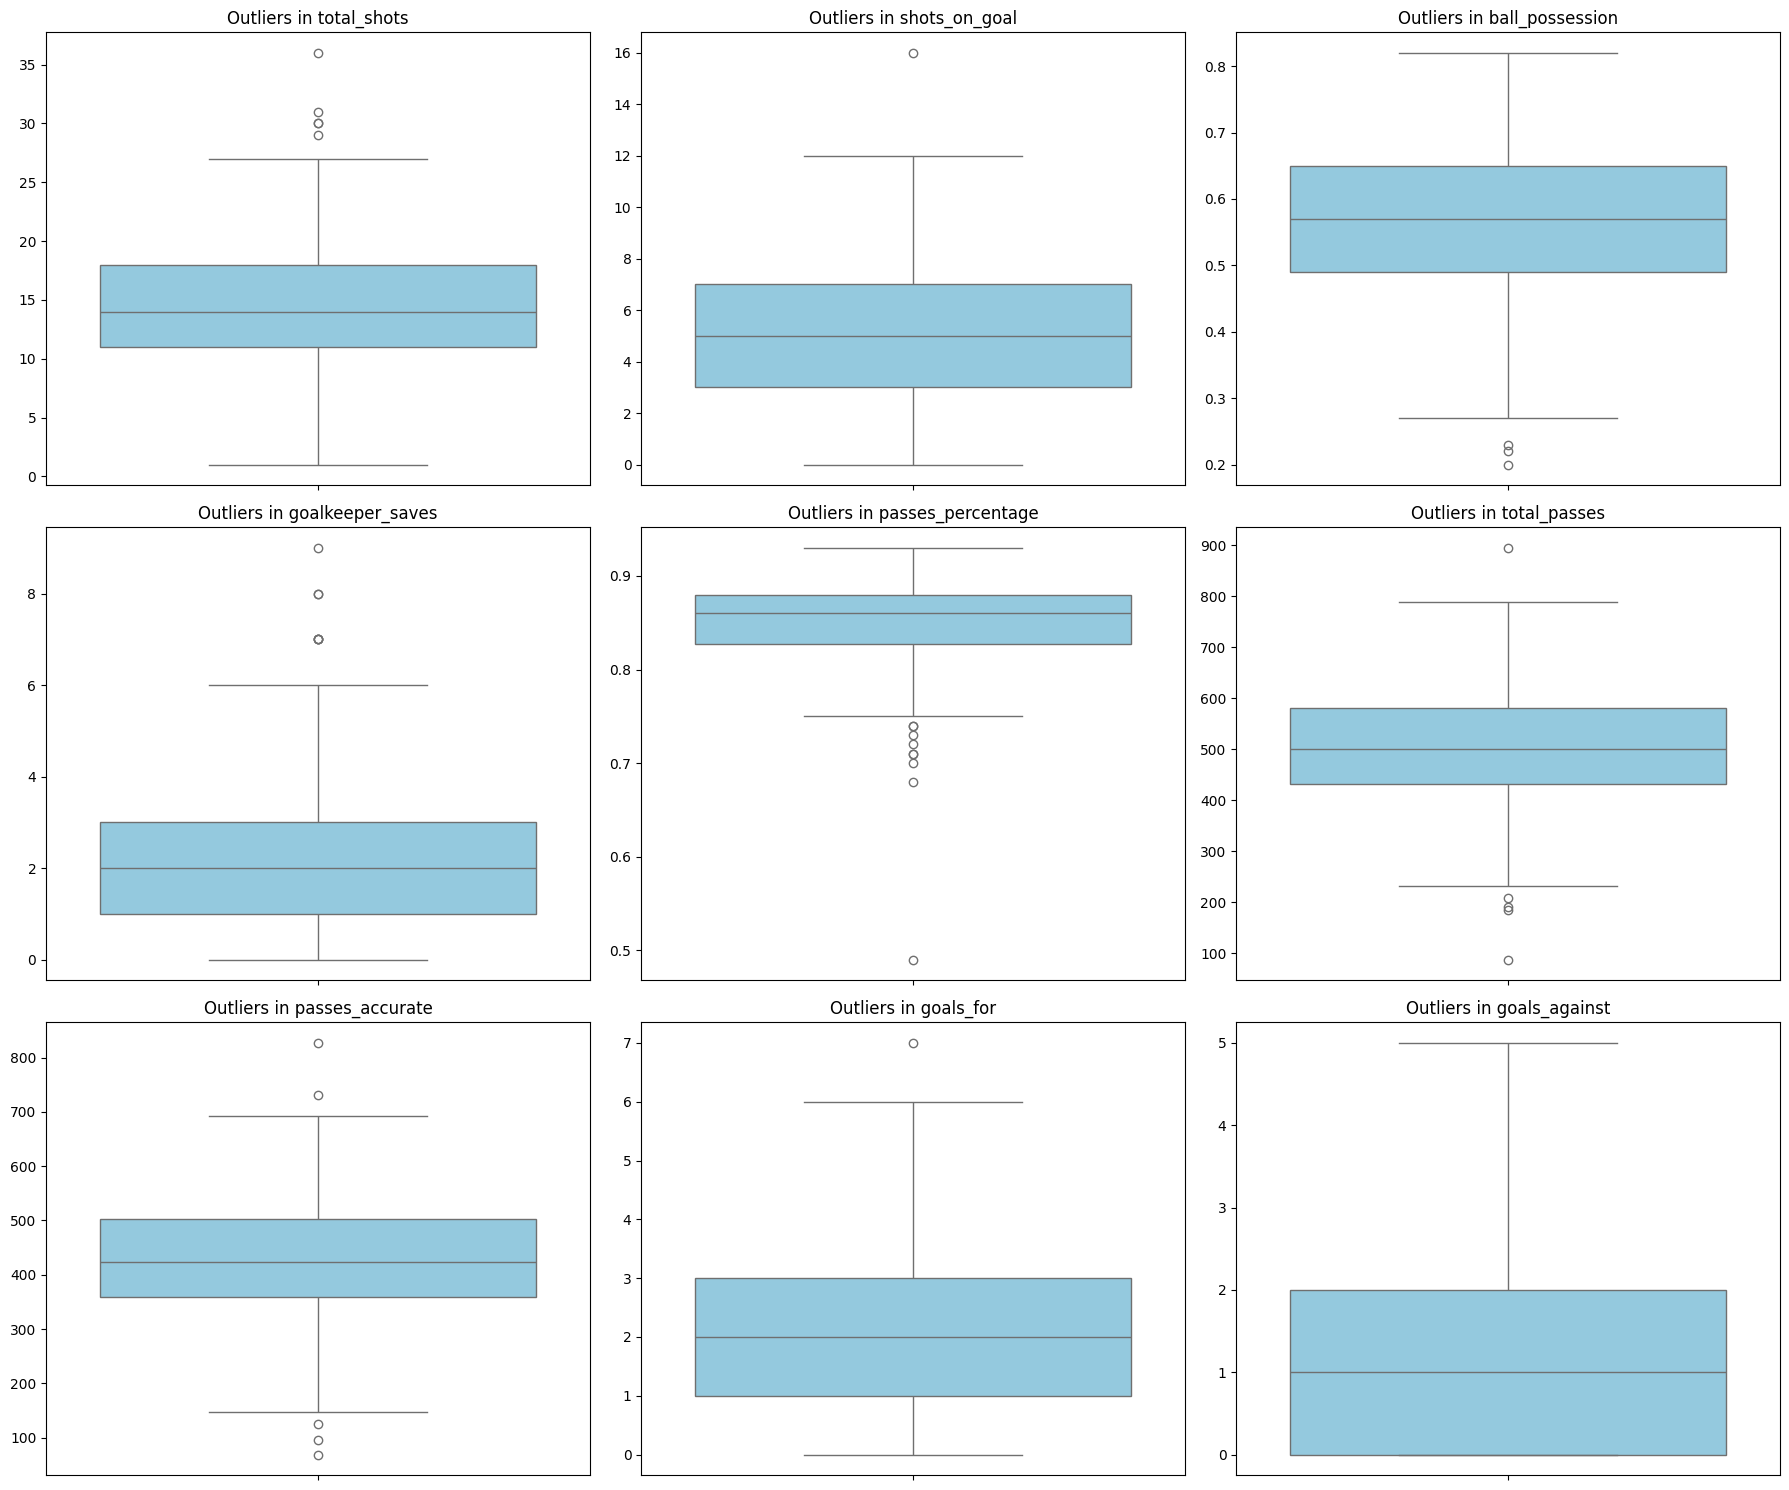

In [30]:
colums_analyze = ['total_shots', 'shots_on_goal', 'ball_possession',
                  'goalkeeper_saves', 'passes_percentage', 'total_passes',
                  'passes_accurate', 'goals_for', 'goals_against']

# Configuramos el número de columnas y calculamos las filas necesarias
cols = 3
rows = math.ceil(len(colums_analyze) / cols)

# Creamos la base del cuadro (el lienzo grande)
fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))
axes = axes.flatten() # Aplanamos la matriz de ejes para iterar fácilmente

for i, col in enumerate(colums_analyze):
    sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Outliers in {col}', fontsize=12)
    axes[i].set_ylabel('') # Limpiamos el nombre del eje Y para que se vea más estético

plt.tight_layout()
plt.show()

### **<font color='pink'>Victorias, Empates y Derrotas (local vs visitante)</font>**

In [31]:
match_is_home_count = df.groupby(['is_home', 'result_num']).size().unstack(fill_value=0)
match_is_home_count

/tmp/ipykernel_2986/632641939.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  match_is_home_count = df.groupby(['is_home', 'result_num']).size().unstack(fill_value=0)


result_num,0,1,2
is_home,,,
True,18,18,95
False,33,27,73


In [32]:
result = pd.crosstab(df['is_home'], df['result_num'], normalize='index')
result

result_num,0,1,2
is_home,,,
True,0.137405,0.137405,0.725191
False,0.248120,0.203008,0.548872


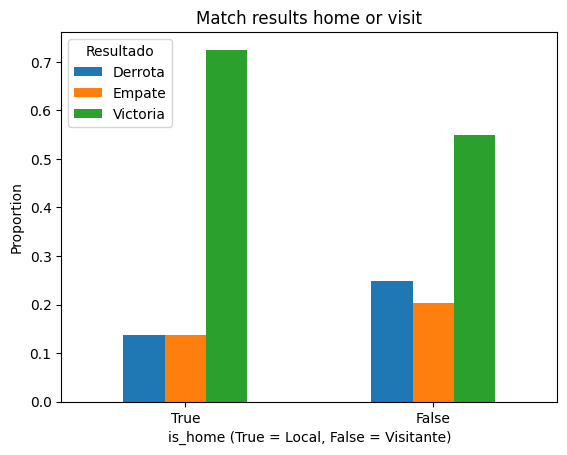

In [33]:
result.plot(kind='bar')

plt.title('Match results home or visit')
plt.xlabel('is_home (True = Local, False = Visitante)')
plt.ylabel('Proportion')
plt.legend(title='Resultado', labels=['Derrota', 'Empate', 'Victoria'], loc='upper left')
plt.xticks(rotation=0)

plt.show()

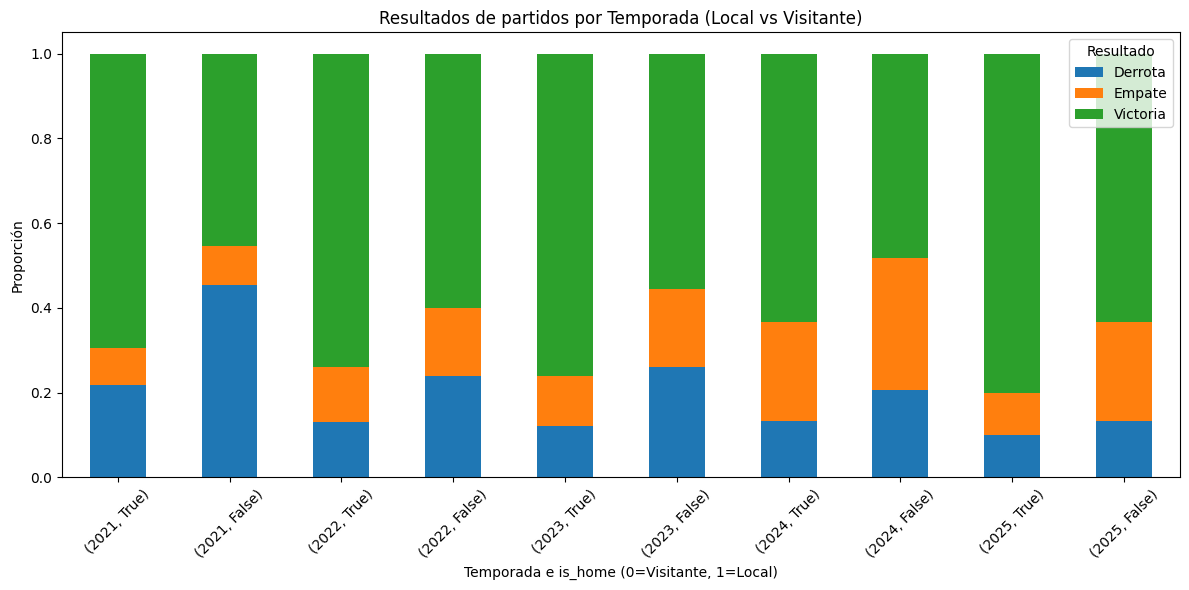

In [34]:
result_evolucion = pd.crosstab(index=[df['season'], df['is_home']],
                               columns=df['result_num'],
                               normalize='index')

ax = result_evolucion.plot(kind='bar', figsize=(12, 6), stacked=True)

plt.title('Resultados de partidos por Temporada (Local vs Visitante)')
plt.xlabel('Temporada e is_home (0=Visitante, 1=Local)')
plt.ylabel('Proporción')
plt.legend(title='Resultado', labels=['Derrota', 'Empate', 'Victoria'], loc='upper right')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### **<font color='pink'>Histogramas</font>**

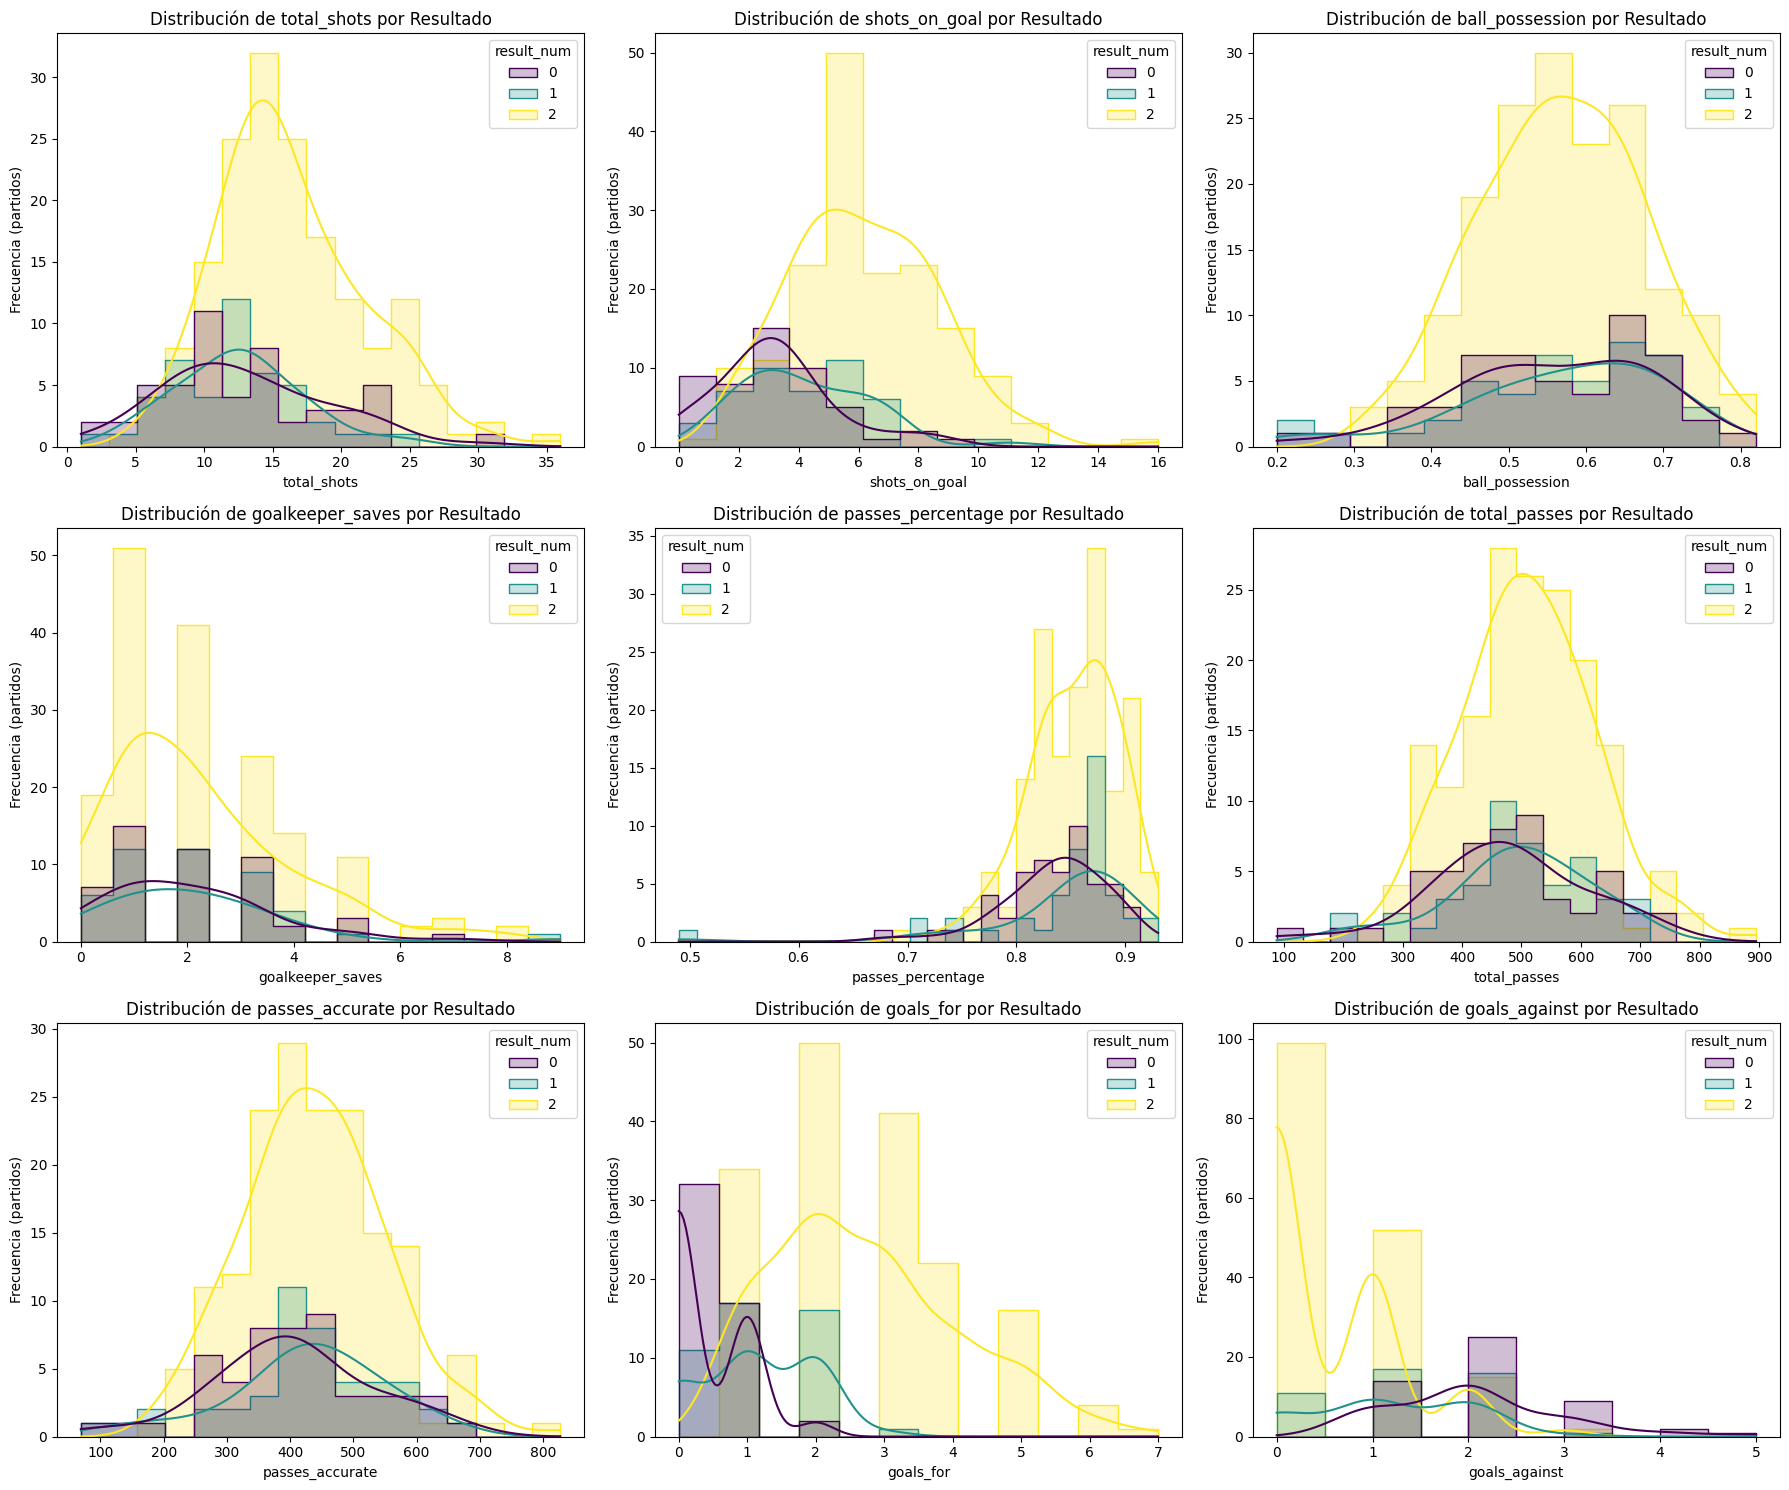

In [35]:
colums_analyze = ['total_shots', 'shots_on_goal', 'ball_possession',
                  'goalkeeper_saves', 'passes_percentage', 'total_passes',
                  'passes_accurate', 'goals_for', 'goals_against']

cols = 3
rows = math.ceil(len(colums_analyze) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(18, rows * 5))
axes = axes.flatten()

for i, col in enumerate(colums_analyze):
    # Creamos el histograma
    # hue='result_num' separa por colores según el resultado
    # kde=True añade una línea de suavizado para ver mejor la tendencia
    sns.histplot(data=df,
                 x=col,
                 hue='result_num',
                 kde=True,
                 element="step",
                 ax=axes[i],
                 palette='viridis')

    axes[i].set_title(f'Distribución de {col} por Resultado', fontsize=12)
    axes[i].set_xlabel(f'{col}')
    axes[i].set_ylabel('Frecuencia (partidos)')

plt.tight_layout()
plt.show()

### **<font color='pink'>Valores nulos</font>**

<Axes: >

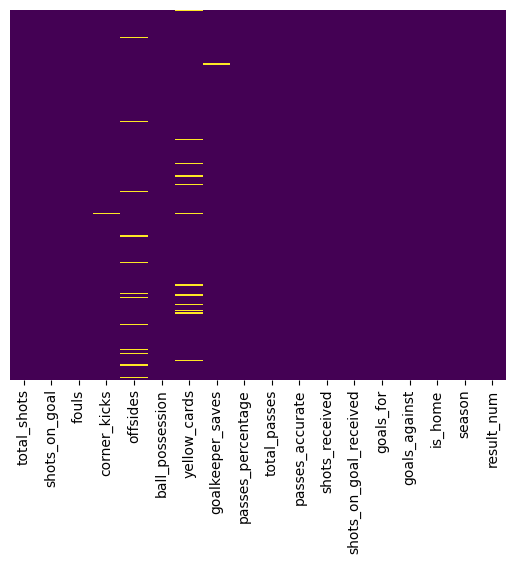

In [36]:
sns.heatmap(df.isnull(),
            cbar=False,
            yticklabels=False,
            cmap='viridis')

### **<font color='green'>Preprocesamiento (Eliminar columunas con valores faltantes)</font>**

In [37]:
columns_drop = ['offsides', 'yellow_cards']

df_production = df.drop(columns_drop, axis=1)

df_production.head(2)

,total_shots,shots_on_goal,fouls,corner_kicks,ball_possession,goalkeeper_saves,passes_percentage,total_passes,passes_accurate,shots_received,shots_on_goal_received,goals_for,goals_against,is_home,season,result_num
0,22,4,8,5.0,0.65,1,0.86,568,488,8,3,0,2,False,2021,0
1,6,3,10,9.0,0.35,3,0.79,335,266,22,5,0,2,True,2021,0


In [38]:
display(df_production.isnull().sum())

,0
total_shots,0
shots_on_goal,0
fouls,0
corner_kicks,1
ball_possession,0
goalkeeper_saves,1
passes_percentage,0
total_passes,0
passes_accurate,0
shots_received,0


## 🔨 <font color=#258FE8>**Ingeniería de características**</font> (Avance 2)

### Obtener dataset de partidos (información general)

In [39]:
df_api = get_general_results_matches_all_teams()

SEASON: 2021
ID LEAGUE: 2
No. errors:  0
No. results:  218
----



ID LEAGUE: 3
No. errors:  0
No. results:  177
----



ID LEAGUE: 39
No. errors:  0
No. results:  380
----



ID LEAGUE: 45
No. errors:  0
No. results:  868
----



ID LEAGUE: 48
No. errors:  0
No. results:  93
----



ID LEAGUE: 528
No. errors:  0
No. results:  1
----



ID LEAGUE: 667
No. errors:  0
No. results:  6852
----



ID LEAGUE: 866
No. errors:  0
No. results:  1
----



ID LEAGUE: 937
No. errors:  0
No. results:  0
----



SEASON: 2022
ID LEAGUE: 2
No. errors:  0
No. results:  214
----



ID LEAGUE: 3
No. errors:  0
No. results:  175
----



ID LEAGUE: 39
No. errors:  0
No. results:  380
----



ID LEAGUE: 45
No. errors:  0
No. results:  889
----



ID LEAGUE: 48
No. errors:  0
No. results:  93
----



ID LEAGUE: 528
No. errors:  0
No. results:  1
----



ID LEAGUE: 667
No. errors:  0
No. results:  5509
----



ID LEAGUE: 866
No. errors:  0
No. results:  1
----



ID LEAGUE: 937
No. errors:  0
No. results:  1


In [40]:
df = df_api.copy()

In [41]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(by='date').reset_index(drop=True)
display(df.shape)
display(df.head(2))

(41641, 7)

,fixture_id,season,date,home_team,away_team,home_goals,away_goals
0,738437,2021,2021-01-01 09:00:00+00:00,Sanna Khanh Hoa,Da Nang,2,3
1,738438,2021,2021-01-01 11:00:00+00:00,Binh Duong,Nam Dinh,2,1


### **<font color='orange'>ELO Ranking avanzado</font>**

#### Inicializamos a todos los equipos otorgando un valor inicial de 1,500 pts

In [42]:
teams = pd.concat([df['home_team'], df['away_team']]).unique()
elo_dictionary = {team: 1500 for team in teams}
elo_dictionary

{'Sanna Khanh Hoa': 1500,
 'Binh Duong': 1500,
 'Ho Chi Minh': 1500,
 'Sai Gon': 1500,
 'Alondras': 1500,
 'Nam Dinh': 1500,
 'Hoang Anh Gia Lai': 1500,
 'Soroksar': 1500,
 'Laredo': 1500,
 'Litex': 1500,
 'Renova': 1500,
 'Chemik Bydgoszcz': 1500,
 'Lokomotiv Sofia': 1500,
 'Akademija Pandev': 1500,
 'Bytovia Bytów': 1500,
 'Śląsk Wrocław II': 1500,
 'Pirin Blagoevgrad': 1500,
 'Sesvete': 1500,
 'Hebar 1918': 1500,
 'Belasitsa': 1500,
 'Borec': 1500,
 'Opatija': 1500,
 'Pogoń Siedlce': 1500,
 'Drita': 1500,
 'Belasica': 1500,
 'CSM Reşiţa': 1500,
 'Strumska Slava': 1500,
 'Petrolul Ploiesti': 1500,
 'Spartak Pleven': 1500,
 'Podbrezová': 1500,
 'Progresul Spartac': 1500,
 'Gyirmot SE': 1500,
 'Polonia Bytom': 1500,
 'Olimpia Elbląg': 1500,
 'Žilina II': 1500,
 'Sokół Ostróda': 1500,
 'Radomiak Radom': 1500,
 'Elana Toruń': 1500,
 'FK Rabotnicki': 1500,
 'Yambol 1915': 1500,
 'FUS Rabat': 1500,
 'Szombathelyi Haladas': 1500,
 'GKS Katowice': 1500,
 'LDU de Quito': 1500,
 'Ohrid': 1500,

#### Función para hacer un reinicio de los pts de los equipos

* Cada nueva temporada tenemos que hacer un reinicio parcial de los pts obtenidos, esto es debido a que los equipos se refuerzan o desarman, cambian de DT, compran y venden jugadores, personal, etc.

* Actualmente nos quedamos con el 0.33% de los puntos obtenidos en la campaña.

In [43]:
def reboot_elo_new_seasson(elo_dictionary):

  for team, elo in elo_dictionary.items():
    #print(team, elo)
    #elo_dictionary[team] = (elo * 0.75) + (1500 * 0.25)
    elo_dictionary[team] = (elo * 0.67) + (1500 * 0.33)

#### Función para crear la tabla ELO hasta el último partido registrado

In [75]:
# HFA = ventaja de local (Home Field Advantage)
# K = Es un valor dinámico (respecto al torneo) para darle variedad a la puntuación
K, HFA = 20, 53
test_reboot_elo_ranking = True

# Listas temporales para guardar el estado ANTES del partido
elo_home_pre = []
elo_away_pre = []

current_year = int(AVAILABLE_SEASSONS[0])

# Recorremos todos los partidos
for index, row in df.iterrows():

  if row['season'] != current_year and test_reboot_elo_ranking:
    display(f"Last year: {current_year} // Current year {row['season']}")
    current_year = row['season']
    reboot_elo_new_seasson(elo_dictionary)

  home = row['home_team']
  away = row['away_team']
  goals_h = row['home_goals']
  goals_a = row['away_goals']

  # 1. Leer el elo actual de los equipos
  elo_current_h = elo_dictionary[home]
  elo_current_a = elo_dictionary[away]


  if index == 0:
    display(home)
    display(away)
    display(f"H: {elo_current_h} // A: {elo_current_a}")

  # 2. Guardarlo para el modelo predictivo
  elo_home_pre.append(elo_current_h)
  elo_away_pre.append(elo_current_a)

  # 3. Calcular la probabilidad con la fórmula de elo
  # Agregamos +100 al local para simular la ventaja de jugar en casa (Home Field Advantage)
  E_home = 1 / (1 + 10 ** (((elo_current_a) - (elo_current_h + HFA)) / 400))
  E_away = 1 - E_home

  # 4. Determinar el resultado real
  # (1 = gana local, 0.5 = empate, 0 = gana visita)
  if goals_h > goals_a:
      S_home, S_away = 1, 0
  elif goals_h == goals_a:
      S_home, S_away = 0.5, 0.5
  else:
      S_home, S_away = 0, 1

  # 5. Multiplicar por el margen de victoria
  # Un 4-0 demuestra más superioridad que un 1-0
  # Usamos la raíz cuadrada de la diferencia para amplificar un resultado grande
  margin_goals = abs(goals_h - goals_a)
  margin_multiplier = math.sqrt(margin_goals) if margin_goals > 0 else 1.0

  # 6. Calcular los puntos ganados en el partido
  change_elo_home = K * margin_multiplier * (S_home - E_home)
  change_elo_away = K * margin_multiplier * (S_away - E_away)

  # 7. Actualizar el diccionario de los equipos con los elo
  elo_dictionary[home] = elo_current_h + change_elo_home
  elo_dictionary[away] = elo_current_a + change_elo_away

  # ¿No se debería ir actualizando el ELO respecto a cada partido?
  # 8. Añadir el elo al dataframe
  df.at[index, 'Elo_Home_Pre'] = elo_current_h
  df.at[index, 'Elo_Away_Pre'] = elo_current_a
  df.at[index, 'Elo_Diff'] = (elo_current_h - elo_current_a)

'Sanna Khanh Hoa'

'Da Nang'

'H: 1500.0000000000005 // A: 1500.0'

'Last year: 2021 // Current year 2022'

'Last year: 2022 // Current year 2021'

...

'Last year: 2026 // Current year 2025'

'Last year: 2025 // Current year 2026'

'Last year: 2026 // Current year 2025'

'Last year: 2025 // Current year 2026'

'Last year: 2026 // Current year 2025'

In [76]:
df

,fixture_id,season,date,home_team,away_team,home_goals,away_goals,Elo_Home_Pre,Elo_Away_Pre,Elo_Diff
0,738437,2021,2021-01-01 09:00:00+00:00,Sanna Khanh Hoa,Da Nang,2,3,1500.000000,1500.000000,4.547474e-13
1,738438,2021,2021-01-01 11:00:00+00:00,Binh Duong,Nam Dinh,2,1,1500.000000,1500.000000,0.000000e+00
2,738439,2021,2021-01-02 10:00:00+00:00,Ho Chi Minh,Ha Noi,2,1,1500.000000,1500.000000,-4.547474e-13
3,738440,2021,2021-01-02 12:30:00+00:00,Sai Gon,Binh Dinh,1,1,1500.000000,1500.000000,0.000000e+00
4,738441,2021,2021-01-02 15:30:00+00:00,Alondras,Coruxo,0,2,1500.000000,1500.000000,-4.547474e-13
...,...,...,...,...,...,...,...,...,...,...
41636,1379331,2025,2026-05-19 18:30:00+00:00,Bournemouth,Manchester City,1,1,1511.672272,1520.942344,-9.270072e+00
41637,1379333,2025,2026-05-19 19:15:00+00:00,Chelsea,Tottenham,2,1,1489.374601,1506.396223,-1.702162e+01
41638,1545278,2026,2026-05-20 16:30:00+00:00,Spelle-Venhaus,Borussia Mönchengladbach,2,6,1500.000000,1500.001937,-1.936790e-03
41639,1545279,2026,2026-05-20 17:00:00+00:00,SV Sandhausen,Eintracht Frankfurt,3,3,1500.000000,1513.674612,-1.367461e+01


In [77]:
#Contador para ver cuántas veces gana el visitante y cuántas veces el local
favorito_local_y_gana = 0
favorito_visita_y_gana = 0
empates_totales = 0

for index, row in df.iterrows():
    # Determinamos qué pasó en la vida real
    if row['home_goals'] > row['away_goals']:
        resultado_real = '1' # Ganó Local
    elif row['home_goals'] == row['away_goals']:
        resultado_real = 'X' # Empate
    else:
        resultado_real = '2' # Ganó Visita

    # Caso A: El Local era el favorito por ELO (Elo_Diff > 0) y cumplió ganando
    if row['Elo_Diff'] > 0 and resultado_real == '1':
        favorito_local_y_gana += 1

    # Caso B: El Visitante era el favorito por ELO (Elo_Diff < 0) y rompió la localía ganando
    elif row['Elo_Diff'] < 0 and resultado_real == '2':
        favorito_visita_y_gana += 1

    # Conteo de empates reales para el contexto general
    if resultado_real == 'X':
        empates_totales += 1

total_partidos = len(df)
pct_local = (favorito_local_y_gana / total_partidos) * 100
pct_visita = (favorito_visita_y_gana / total_partidos) * 100
pct_empates = (empates_totales / total_partidos) * 100

print(f"Veces que el Local era favorito en ELO y SÍ ganó: {favorito_local_y_gana} ({pct_local:.2f}%)")
print(f"Veces que el Visitante era favorito en ELO y SÍ ganó: {favorito_visita_y_gana} ({pct_visita:.2f}%)")
print(f"Empates reales registrados en el dataset: {empates_totales} ({pct_empates:.2f}%)")



Veces que el Local era favorito en ELO y SÍ ganó: 10146 (24.37%)
Veces que el Visitante era favorito en ELO y SÍ ganó: 7796 (18.72%)
Empates reales registrados en el dataset: 8343 (20.04%)


In [131]:
#Contador para ver cuántas veces gana el visitante sin ser favorito
no_favorito_visita_y_gana = 0


for index, row in df.iterrows():
    # Determinamos qué pasó en la vida real
    if row['home_goals'] > row['away_goals']:
        resultado_real = '1' # Ganó Local
    elif row['home_goals'] == row['away_goals']:
        resultado_real = 'X' # Empate
    else:
        resultado_real = '2' # Ganó Visita

    # Caso A: El Visitante no era el favorito por ELO (Elo_Diff > 0) y rompió la localía ganando
    if row['Elo_Diff'] > 0 and resultado_real == '2':
      no_favorito_visita_y_gana += 1


total_partidos = len(df)
pct_visita = (no_favorito_visita_y_gana / total_partidos) * 100

print(f"Veces que el Visitante no era favorito en ELO y SÍ ganó: {favorito_visita_y_gana} ({pct_visita:.2f}%)")


Veces que el Visitante no era favorito en ELO y SÍ ganó: 7796 (14.15%)


#### <font color=pink>Observar el ELO ranking final</font>

In [78]:
display(pd.Series(elo_dictionary).sort_values(ascending=False).round(2).head(30))

,0
Aston Villa,1522.41
Borussia Mönchengladbach,1515.43
Manchester City,1509.96
Eintracht Frankfurt,1509.92
Arsenal,1508.80
Bournemouth,1504.68
Manchester United,1504.54
Newcastle,1504.01
Leeds,1503.98
Nottingham Forest,1501.47


In [79]:
len(df)

41641

### **Standard Scaler**

In [80]:
df.head(2)

,fixture_id,season,date,home_team,away_team,home_goals,away_goals,Elo_Home_Pre,Elo_Away_Pre,Elo_Diff
0,738437,2021,2021-01-01 09:00:00+00:00,Sanna Khanh Hoa,Da Nang,2,3,1500.0,1500.0,4.547474e-13
1,738438,2021,2021-01-01 11:00:00+00:00,Binh Duong,Nam Dinh,2,1,1500.0,1500.0,0.000000e+00


In [81]:
# El número de partidos que tienen exactamente 1500
# estos partidos son los que iniciaron nuestra puntuación elo
df_test = df[df['Elo_Home_Pre'] == 1500].copy()
len(df_test)

4984

In [82]:
# Eliminamos los primeros partidos que ayudaron a inicializar
# Son los que exactamente tienen 1,500 pts
df_train = df[df['Elo_Home_Pre'] != 1500].copy()
len(df_train)

36657

In [83]:
SCALER = StandardScaler()

X_local = df_train[['Elo_Home_Pre', 'Elo_Away_Pre']]
y_local = df_train['home_goals']

X_away = df_train[['Elo_Away_Pre', 'Elo_Home_Pre']]
y_away = df_train['away_goals']

X_local_scaled = SCALER.fit_transform(X_local)
X_away_scaled = SCALER.fit_transform(X_away)


In [84]:
display(X_local_scaled)
display(X_away_scaled)

array([[-0.2571613 , -0.2468332 ],
       [-0.61327991, -0.2468332 ],
       [ 0.09895732, -0.74193037],
       ...,
       [-0.70304701,  0.02820794],
       [-0.2571613 ,  0.34118269],
       [-0.21523068, -0.13726481]])

array([[-0.2468332 , -0.2571613 ],
       [-0.2468332 , -0.61327991],
       [-0.74193037,  0.09895732],
       ...,
       [ 0.02820794, -0.70304701],
       [ 0.34118269, -0.2571613 ],
       [-0.13726481, -0.21523068]])

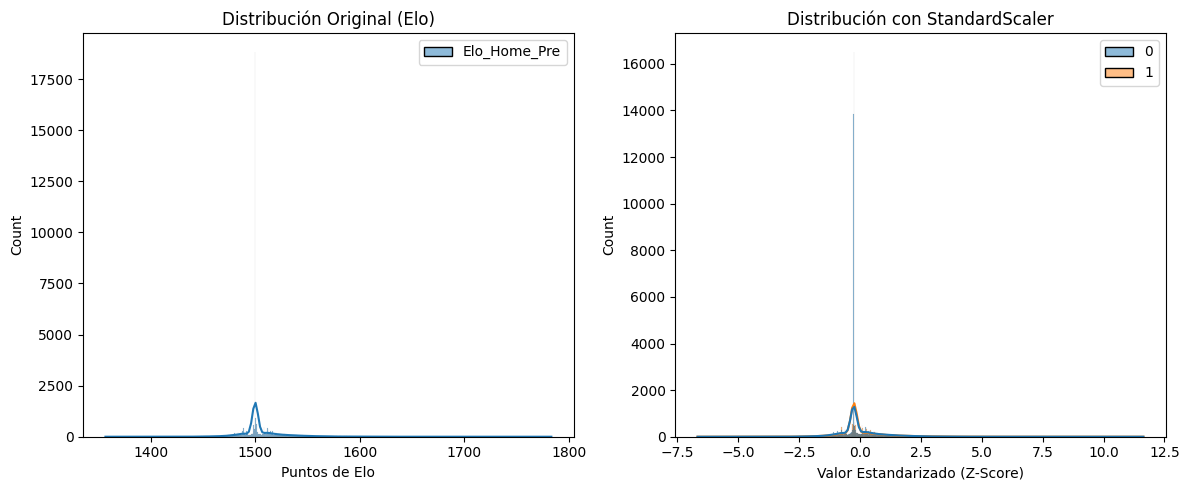

In [85]:
elo_original = df[['Elo_Home_Pre']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico 1: Antes del escalado
sns.histplot(elo_original, kde=True, color='skyblue', ax=ax1)
ax1.set_title('Distribución Original (Elo)')
ax1.set_xlabel('Puntos de Elo')

# Gráfico 2: Después del escalado
sns.histplot(X_local_scaled, kde=True, color='olive', ax=ax2)
ax2.set_title('Distribución con StandardScaler')
ax2.set_xlabel('Valor Estandarizado (Z-Score)')

plt.tight_layout()
plt.show()

## 🏁 <font color=#258FE8>**Baseline**</font> (Avance 3)

In [86]:
df_train.head(2)

,fixture_id,season,date,home_team,away_team,home_goals,away_goals,Elo_Home_Pre,Elo_Away_Pre,Elo_Diff
0,738437,2021,2021-01-01 09:00:00+00:00,Sanna Khanh Hoa,Da Nang,2,3,1500.000000,1500.0,4.547474e-13
5,738442,2021,2021-01-03 09:00:00+00:00,Nam Dinh,Hoang Anh Gia Lai,1,1,1491.513739,1500.0,-8.486261e+00


### Train

In [87]:
# 1. PREPARACIÓN DE DATOS
# Features: Usamos el Elo de ambos para capturar la diferencia de nivel
X_local = df_train[['Elo_Home_Pre', 'Elo_Away_Pre']]
y_local = df_train['home_goals']

# Para el visitante invertimos el orden lógico para el modelo
X_visita = df_train[['Elo_Away_Pre', 'Elo_Home_Pre']]
y_visita = df_train['away_goals']

# 2. ENTRENAMIENTO DEL MODELO POISSON
modelo_local = make_pipeline(StandardScaler(), PoissonRegressor())
modelo_visita = make_pipeline(StandardScaler(), PoissonRegressor())

modelo_local.fit(X_local, y_local)
modelo_visita.fit(X_visita, y_visita)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('poissonregressor', PoissonRegressor())])

### Inference

In [161]:
# ---------------------------------------------------------
# PREDICCIÓN QUINIELA
# Equipo A vs Equipo B
# ---------------------------------------------------------
def inference_vol1(name_local, name_away):

  print(f"{name_local} vs {name_away}\n")

  elo_equipo_A, elo_equipo_B = elo_dictionary[name_local], elo_dictionary[name_away] # LOCAL / VISITANTE

  elo_diff = elo_equipo_A - elo_equipo_B

  # A. Predecir los Goles Esperados (Lambda)
  lambda_local = modelo_local.predict([[elo_equipo_A, elo_equipo_B]])[0]
  lambda_visita = modelo_visita.predict([[elo_equipo_B, elo_equipo_A]])[0]

  print(f"Goles esperados Local: {lambda_local:.2f}")
  print(f"Goles esperados Visita: {lambda_visita:.2f}\n")

  # B. Simular la Matriz de Marcadores usando la distribución de Poisson
  max_goles = 5 # Marcadores más allá de 5 goles son estadísticamente raros
  prob_victoria_local = 0
  prob_empate = 0
  prob_victoria_visita = 0

  for goles_L in range(max_goles + 1):
      for goles_V in range(max_goles + 1):
          # La probabilidad de un marcador exacto (ej. 2-1) es la multiplicación de las probabilidades independientes de los goles de cada equipo
          prob_marcador = poisson.pmf(goles_L, lambda_local) * poisson.pmf(goles_V, lambda_visita)

          # Clasificar la probabilidad en la cubeta correcta para la quiniela
          if goles_L > goles_V:
              prob_victoria_local += prob_marcador
          elif goles_L == goles_V:
              prob_empate += prob_marcador
          else:
              prob_victoria_visita += prob_marcador


  # AJUSTE MANUAL DE EMPATES (Heurística tipo Dixon-Coles)

  # 1. Definir cuándo aplica el ajuste (ej. si la diferencia de Elo es menor a 200 puntos)
  umbral_elo_parejo = 200
  empuje_empate = 0.04 # Le vamos a sumar 4% al empate

  if abs(elo_diff) < umbral_elo_parejo:
      # Aumentamos el empate
      prob_empate += empuje_empate

      # Calculamos cuánto espacio queda para repartir entre Local y Visita
      espacio_restante = 1.0 - prob_empate

      # ¿Cuánto sumaban las victorias originales?
      suma_victorias_original = prob_victoria_local + prob_victoria_visita

      # Recalculamos las victorias proporcionalmente al espacio que queda
      prob_victoria_local = (prob_victoria_local / suma_victorias_original) * espacio_restante
      prob_victoria_visita = (prob_victoria_visita / suma_victorias_original) * espacio_restante

  # ----------------------------------------------------------------

  print("--- PRONÓSTICO PARA LA QUINIELA ---")
  print(f"Diff {elo_diff}")
  print(f"Probabilidad Local (1): {prob_victoria_local * 100:.1f}%")
  print(f"Probabilidad Empate (X): {prob_empate * 100:.1f}%")
  print(f"Probabilidad Visita (2): {prob_victoria_visita * 100:.1f}%\n")
  #----------------------------------------------------------------
  # Para poder pasar al cálculo de accuracy, guardamos la decisión del modelo:
  # REGLA 1: SI EL VISITANTE TIENE MEJOR ELO Y SU PROBABILIDAD SUPERA EL UMBRAL REALISTA
  # Si el visitante es superior en ELO y la diferencia de probabilidades es menor a 0.22,
  # asumimos que tiene los argumentos deportivos para romper la localía.
  dif_prob = prob_victoria_local - prob_victoria_visita

  #Regla 1, empate si la diferencia de probabilidad es muy corta entre 7.21% y 14% que es el mínimo de diferencia del dataset
  if 0.0721 <= dif_prob <= 0.14:
    resultado_predicho = "X"

  #Regla 2, cuando ELO del visitante es mayor al local y la diferencia de probabilidades es menor a 22%
  elif elo_equipo_B > elo_equipo_A and dif_prob < 0.22:
      resultado_predicho = "2" # Predicción formal: Victoria Visitante

  #Regla 3, cuando la probabilidad de victoria es mayor para el visitante
  elif prob_victoria_visita > prob_victoria_local:
      resultado_predicho = "2" # Predicción formal: Victoria Visitante

  # REGLA 4: CONDICIÓN COMPLEMENTARIA PARA EL LOCAL
  # Si no se cumple lo anterior, pero el local mantiene la ventaja probabilística tradicional,
  elif prob_victoria_local > prob_victoria_visita:
      resultado_predicho = "1" # Predicción formal: Victoria Local

  # REGLA 5: CASOS DE EXCEPCIÓN por defecto
  else:
      resultado_predicho = "1"

  return resultado_predicho

### Testing

In [162]:
print(pd.Series(elo_dictionary).sort_values(ascending=False).round(2).head(25))

Aston Villa                 1522.41
Borussia Mönchengladbach    1515.43
Manchester City             1509.96
Eintracht Frankfurt         1509.92
Arsenal                     1508.80
Bournemouth                 1504.68
Manchester United           1504.54
Newcastle                   1504.01
Leeds                       1503.98
Nottingham Forest           1501.47
Paris Saint Germain         1501.11
Sunderland                  1500.93
Francs Borains              1500.73
Rapid Wien II               1500.73
Metz                        1500.18
SKRA Częstochowa            1500.14
Twente                      1500.06
AS Marsa                    1500.04
The Strongest               1500.03
Tvååker                     1500.03
Honka                       1500.03
Rot-Weiß Essen              1500.03
Provincial Ovalle           1500.02
Pors Grenland               1500.02
Kazincbarcikai              1500.02
dtype: float64


In [163]:
print(pd.Series(elo_dictionary).sort_values(ascending=False).round(2).tail(25))

Real Betis            1499.87
Zaglebie Sosnowiec    1499.86
Celta Vigo            1499.84
Bologna               1499.84
Brighton              1499.47
SC Braga              1499.29
Leobendorf            1499.27
Southampton           1499.27
Chelsea               1499.26
SV Sandhausen         1499.24
Seraing United        1499.09
Bayern München        1499.02
Tottenham             1498.85
Brentford             1498.79
Atletico Madrid       1498.09
Liverpool             1496.98
Fulham                1495.93
Everton               1495.46
Wolves                1495.07
Burnley               1494.90
Crystal Palace        1493.71
West Ham              1493.51
RW Frankfurt          1490.84
Spelle-Venhaus        1484.57
SC Freiburg           1481.13
dtype: float64


In [164]:
name_local = "Arsenal"
name_away = "Aston Villa"

print(elo_dictionary[name_local])
print(elo_dictionary[name_away])

inference_vol1(name_local, name_away)

1508.7962430356793
1522.414954315972
Arsenal vs Aston Villa

Goles esperados Local: 1.78
Goles esperados Visita: 1.45

--- PRONÓSTICO PARA LA QUINIELA ---
Diff -13.6187112802927
Probabilidad Local (1): 42.9%
Probabilidad Empate (X): 27.0%
Probabilidad Visita (2): 30.2%



'X'

### Evaluation Metrics

In [146]:
import numpy as np

# Listas para almacenar las diferencias encontradas
lista_diferencias = []
ejemplos_impresos = 0

print("=== INICIANDO AUDITORÍA DE DIFERENCIAS DE PROBABILIDAD ===")

# NOTA: Asegúrate de que 'df_test' o tu bucle use los nombres reales de tus columnas
for index, row in df.iterrows():
    name_local = row['home_team']  # Cambia por el nombre real de tu columna local
    name_away = row['away_team']  # Cambia por el nombre real de tu columna visitante

    if name_local in elo_dictionary and name_away in elo_dictionary:
        elo_equipo_A = elo_dictionary[name_local]
        elo_equipo_B = elo_dictionary[name_away]

        # Predecir tasas Lambda
        lambda_local = modelo_local.predict([[elo_equipo_A, elo_equipo_B]])[0]
        lambda_visita = modelo_visita.predict([[elo_equipo_B, elo_equipo_A]])[0]

        # Simular Poisson
        prob_victoria_local = 0
        prob_empate = 0
        prob_victoria_visita = 0
        max_goles = 5

        for goles_L in range(max_goles + 1):
            for goles_V in range(max_goles + 1):
                prob_marcador = poisson.pmf(goles_L, lambda_local) * poisson.pmf(goles_V, lambda_visita)
                if goles_L > goles_V:
                    prob_victoria_local += prob_marcador
                elif goles_L == goles_V:
                    prob_empate += prob_marcador
                else:
                    prob_victoria_visita += prob_marcador

        # Aplicar el ajuste original de empates de Mateo
        elo_diff = elo_equipo_A - elo_equipo_B
        if abs(elo_diff) < 200:
            prob_empate += 0.04
            espacio_restante = 1.0 - prob_empate
            suma_victorias_original = prob_victoria_local + prob_victoria_visita
            prob_victoria_local = (prob_victoria_local / suma_victorias_original) * espacio_restante
            prob_victoria_visita = (prob_victoria_visita / suma_victorias_original) * espacio_restante

        # Calcular la diferencia neta
        dif_prob = prob_victoria_local - prob_victoria_visita
        lista_diferencias.append(dif_prob)


# Convertir a array de numpy para estadísticas globales
lista_diferencias = np.array(lista_diferencias)

print("\n=== REPORTE DE DISTRIBUCIÓN DE FRONTERAS ===")
print(f"Partidos con diferencia <= 5%: {np.sum(abs(lista_diferencias) <= 0.05)}")
print(f"Partidos con diferencia <= 10%: {np.sum(abs(lista_diferencias) <= 0.10)}")
print(f"Partidos con diferencia <= 15%: {np.sum(abs(lista_diferencias) <= 0.15)}")
print(f"Partidos con diferencia <= 20%: {np.sum(abs(lista_diferencias) <= 0.20)}")
print(f"Diferencia mínima absoluta en todo el dataset: {abs(lista_diferencias).min()*100:.2f}%")
print(f"Diferencia promedio en todo el dataset: {lista_diferencias.mean()*100:.2f}%")

=== INICIANDO AUDITORÍA DE DIFERENCIAS DE PROBABILIDAD ===
Match: Crystal Palace vs Aston Villa | Dif: 9.72% (Local: 41.3%, Visita: 31.6%)
Match: West Ham vs Aston Villa | Dif: 9.68% (Local: 41.3%, Visita: 31.6%)
Match: Wolves vs Aston Villa | Dif: 9.99% (Local: 41.5%, Visita: 31.5%)
Match: Burnley vs Aston Villa | Dif: 9.95% (Local: 41.4%, Visita: 31.5%)
Match: Crystal Palace vs Aston Villa | Dif: 9.72% (Local: 41.3%, Visita: 31.6%)
Match: West Ham vs Aston Villa | Dif: 9.68% (Local: 41.3%, Visita: 31.6%)
Match: Wolves vs Aston Villa | Dif: 9.99% (Local: 41.5%, Visita: 31.5%)
Match: Burnley vs Aston Villa | Dif: 9.95% (Local: 41.4%, Visita: 31.5%)
Match: Wolves vs Aston Villa | Dif: 9.99% (Local: 41.5%, Visita: 31.5%)
Match: West Ham vs Aston Villa | Dif: 9.68% (Local: 41.3%, Visita: 31.6%)

=== REPORTE DE DISTRIBUCIÓN DE FRONTERAS ===
Partidos con diferencia <= 5%: 0
Partidos con diferencia <= 10%: 21
Partidos con diferencia <= 15%: 841
Partidos con diferencia <= 20%: 41518
Diferenci

In [166]:
warnings.filterwarnings("ignore")

y_true = []
y_pred = []
exitos = 0
omitidos = 0

# Evaluamos uno a uno los 41,641 partidos del DataFrame
for index, row in df.iterrows():
    local = row['home_team']
    visita = row['away_team']

    # 1. Validar que ambos equipos existan en las llaves del elo_dictionary
    if local not in elo_dictionary or visita not in elo_dictionary:
        omitidos += 1
        continue

    # 2. Determinar la etiqueta REAL del partido (Ground Truth)
    if row['home_goals'] > row['away_goals']:
        real = '1'  # Local
    elif row['home_goals'] == row['away_goals']:
        real = 'X'  # Empate
    else:
        real = '2'  # Visita

    try:
        # 3. Forzar a que la salida de texto no se trabe en consolas masivas (Silenciado dinámico)
        import sys, os
        actual_stdout = sys.stdout
        sys.stdout = open(os.devnull, 'w')

        # 4. Llamamos a la función inference_vol1
        prediccion = inference_vol1(local, visita)

        # Restauramos canal de texto
        sys.stdout = actual_stdout

        if prediccion is not None:
            y_true.append(real)
            y_pred.append(prediccion)
            exitos += 1

            # Control de avance visual
            if exitos % 5000 == 0:
                print(f"-> {exitos} partidos analizados con éxito...")
    except Exception as e:
        sys.stdout = actual_stdout
        errores_conteo += 1
        continue

print("\n=== PROCESAMIENTO FINALIZADO ===")
print(f"Partidos evaluados con éxito: {exitos}")
print(f"Partidos omitidos por ausencia en diccionario: {omitidos}\n")



-> 5000 partidos analizados con éxito...
-> 10000 partidos analizados con éxito...
-> 15000 partidos analizados con éxito...
-> 20000 partidos analizados con éxito...
-> 25000 partidos analizados con éxito...
-> 30000 partidos analizados con éxito...
-> 35000 partidos analizados con éxito...
-> 40000 partidos analizados con éxito...

=== PROCESAMIENTO FINALIZADO ===
Partidos evaluados con éxito: 41641
Partidos omitidos por ausencia en diccionario: 0



Accuracy Global en Test: 46.54%

=== REPORTE DE CLASIFICACIÓN ===
              precision    recall  f1-score   support

   Local (1)       0.49      0.74      0.59     18835
  Empate (X)       0.21      0.01      0.02      8343
  Visita (2)       0.41      0.37      0.39     14463

    accuracy                           0.47     41641
   macro avg       0.37      0.37      0.33     41641
weighted avg       0.41      0.47      0.41     41641



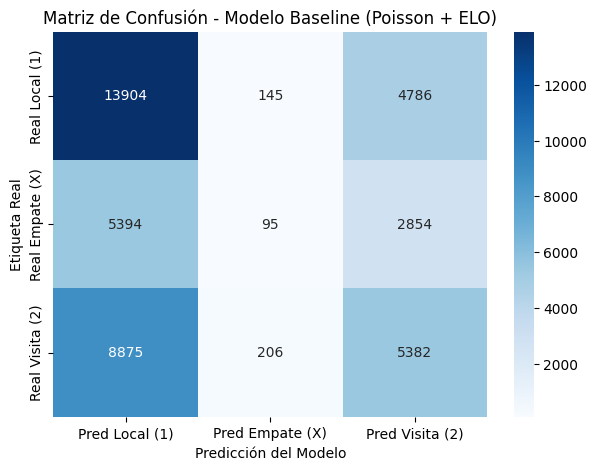

In [167]:
# CÁLCULO DE MÉTRICAS Y GRÁFICA DE LA MATRIZ DE CONFUSIÓN

if len(y_true) > 0:
    accuracy_test = accuracy_score(y_true, y_pred)
    matriz_conf = confusion_matrix(y_true, y_pred, labels=['1', 'X', '2'])
    reporte = classification_report(
        y_true, y_pred,
        labels=['1', 'X', '2'],
        target_names=['Local (1)', 'Empate (X)', 'Visita (2)'],
        zero_division=0
    )

    print(f"Accuracy Global en Test: {accuracy_test * 100:.2f}%\n")
    print("=== REPORTE DE CLASIFICACIÓN ===")
    print(reporte)

    # Dibujar la matriz de confusión gráfica
    plt.figure(figsize=(7, 5))
    sns.heatmap(matriz_conf, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred Local (1)', 'Pred Empate (X)', 'Pred Visita (2)'],
                yticklabels=['Real Local (1)', 'Real Empate (X)', 'Real Visita (2)'])
    plt.title("Matriz de Confusión - Modelo Baseline (Poisson + ELO)")
    plt.ylabel("Etiqueta Real")
    plt.xlabel("Predicción del Modelo")
    plt.show()
else:
    print("Asegúrate de correr las celdas donde entrenas 'modelo_local' y 'modelo_visita'.")